# *Ido Weinstock - HW3 DS course*

## *1. Dataset Selection*

### *Context*

This assignment applies unsupervised learning — clustering, dimensionality reduction (PCA),
and multi-dimensional anomaly detection — to a dataset with no ground-truth labels.
Unlike HW2, there is no target variable to predict; the goal is to discover structure,
redundancy, and abnormal behavior directly from the geometry of the data.

### *Attribute*

**Source:** Kaggle, "Credit Card Dataset for Clustering" (uploaded by arjunbhasin2013),
originally compiled for a customer-segmentation case study of an active credit card
holder base over a 6-month period. The exact issuing institution is not disclosed
(standard practice for financial customer data).

**Why it was collected:** to enable marketing/segmentation strategies for credit card
customers based on usage behavior, without any predefined "type" of customer.

**Who collected it:** not publicly attributed beyond the Kaggle uploader; treated here
as a benchmark dataset for unsupervised learning.

**Rows / Columns:** 8,950 customers x 18 columns (1 identifier + 17 numerical features).

| Feature | Description |
|---|---|
| `CUST_ID` | Unique customer identifier (dropped from analysis, used as index) |
| `BALANCE` | Balance amount left in the account |
| `BALANCE_FREQUENCY` | How frequently the balance is updated (0-1) |
| `PURCHASES` | Total purchase amount |
| `ONEOFF_PURCHASES` | Max purchase amount done in one go |
| `INSTALLMENTS_PURCHASES` | Total purchases made in installments |
| `CASH_ADVANCE` | Cash in advance given by the user |
| `PURCHASES_FREQUENCY` | How frequently purchases are made (0-1) |
| `ONEOFF_PURCHASES_FREQUENCY` | How frequently one-off purchases happen (0-1) |
| `PURCHASES_INSTALLMENTS_FREQUENCY` | How frequently installment purchases happen (0-1) |
| `CASH_ADVANCE_FREQUENCY` | How frequently cash in advance is taken (0-1) |
| `CASH_ADVANCE_TRX` | Number of cash-advance transactions |
| `PURCHASES_TRX` | Number of purchase transactions |
| `CREDIT_LIMIT` | Credit card limit |
| `PAYMENTS` | Total payments made by the user |
| `MINIMUM_PAYMENTS` | Minimum payments made by the user |
| `PRC_FULL_PAYMENT` | Percent of full payments paid |
| `TENURE` | Tenure of credit card service for the user (see note below — exact reference period is not documented) |

**Possible limitations / biases:**
- No demographic info (age, gender, income) — cannot check whether usage patterns
  correlate with, or are biased by, protected attributes.
- Single 6-month snapshot — no seasonality, no way to distinguish a one-time spender
  from a genuinely new customer.
- The `_FREQUENCY` features are the average of a binary monthly flag ("did this happen
  this month?") across the 6-month observation window. This means each of them can only
  take one of 7 discrete values — {0, 1/6, 2/6, 3/6, 4/6, 5/6, 1} — not a true continuum.
  They also compress a lot of temporal information into a single number: a customer who
  was active for the first 3 months and then stopped looks identical to one who was
  active every other month (both score 0.5), even though the underlying behavior
  (churn vs. steady intermittent use) is very different.
- `TENURE`'s exact definition is ambiguous. The official data dictionary only states
  "Tenure of credit card service for user," without specifying the reference period.
  Empirically, `TENURE` ranges from 6 to 12 (median = 75th percentile = 12) — if this
  represented the customer's full relationship length with the issuer, values well above
  12 would be expected (credit cards are commonly held for years). The observed range
  instead suggests `TENURE` is more likely measured within some fixed observation window
  (plausibly 12 months) rather than as a true lifetime tenure — but this is an inference
  from the data's shape, not a documented fact, and is treated as an open ambiguity in
  this analysis rather than a settled interpretation.

#### *Feature Groups & Business Context*

To make the 17 features easier to reason about, they can be grouped into five business
categories:

**Account Balance**
- `BALANCE` — how much available balance the customer has on the card (like a checking
  account balance, not a debt).
- `BALANCE_FREQUENCY` — how often (out of the 6-month window) the balance was updated.
  Higher = more frequent account activity.

**Purchase Behavior**
- `PURCHASES` — total dollar amount of all purchases.
- `ONEOFF_PURCHASES` — the largest amount paid in a **single** transaction (not split
  into installments) — e.g. buying a TV in one payment.
- `INSTALLMENTS_PURCHASES` — total amount of purchases paid **in installments**.
- `PURCHASES_TRX` — the **number** of purchase transactions (a count, not an amount).
- `PURCHASES_FREQUENCY` / `ONEOFF_PURCHASES_FREQUENCY` /
  `PURCHASES_INSTALLMENTS_FREQUENCY` — how many of the 6 months included at least one
  purchase (overall / one-off / installment, respectively).

Note: `PURCHASES` ≈ `ONEOFF_PURCHASES` + `INSTALLMENTS_PURCHASES` — the two components
nearly add up to the total, which explains their strong correlation.

**Cash Advance**
A cash advance is a different action from a purchase — the customer withdraws cash
directly against the credit line (typically at a higher interest rate, functioning as a
short-term loan).
- `CASH_ADVANCE` — total cash withdrawn.
- `CASH_ADVANCE_TRX` — number of cash-advance transactions.
- `CASH_ADVANCE_FREQUENCY` — how many of the 6 months included a cash advance.

The negative correlation observed earlier between purchase activity and cash-advance
activity suggests two distinct customer "styles" — purchase-driven vs. cash-advance-driven
— a potentially useful signal for the clustering stage (Section 4).

**Credit Limit & Repayment**
- `CREDIT_LIMIT` — the maximum credit line approved by the issuer.
- `PAYMENTS` — the amount the customer actually paid back toward their balance.
- `MINIMUM_PAYMENTS` — the minimum required payment for the period (like the "minimum
  payment due" on a credit card statement).
- `PRC_FULL_PAYMENT` — the fraction of the 6 months in which the customer paid the
  **full** balance rather than just the minimum — higher values indicate a customer who
  doesn't carry a revolving debt.

**Tenure**
- `TENURE` — how many months the customer has held the card overall — distinct from the
  6-month window used to measure the behavioral features above (see the limitations note
  in the Attribute section).

**Engineered Feature**
- `MINIMUM_PAYMENTS_WAS_MISSING` — a binary flag created during preprocessing (1 = the
  customer's original `MINIMUM_PAYMENTS` value was missing before median imputation).
  Not part of the original dataset.

**Worked example:** a customer with `PURCHASES=1500`, `PURCHASES_FREQUENCY=0.83` (active
5 of 6 months), `ONEOFF_PURCHASES=1200`, `CASH_ADVANCE=0`, and `PRC_FULL_PAYMENT=1.0` is a
high-spending, consistently active customer who mostly makes large one-off purchases,
never takes cash advances, and always pays off the full balance — a "responsible premium
customer" profile, exactly the kind of pattern the clustering stage (Section 4) should be
able to recover.

## *Setup*

### *Imports*

In [101]:
import pandas as pd
import numpy as np
import plotnine as pln
from scipy.stats import skew, kurtosis
import kagglehub

pd.set_option('display.max_columns', None)

### *Dataset Loading*

In [102]:
dataset_path = kagglehub.dataset_download("arjunbhasin2013/ccdata")
df = pd.read_csv(f"{dataset_path}/CC GENERAL.csv")

df = df.set_index("CUST_ID")  # identifier, not a feature for unsupervised analysis

df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
CUST_ID,,,,,,,,,,,,,,,,,
C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## *2. Exploratory Data Analysis*

### *Structural Analysis*

In [103]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nData types:\n{df.dtypes.value_counts()}")

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary[missing_summary["missing_count"] > 0]

Shape: 8950 rows, 17 columns

Data types:
float64    14
int64       3
Name: count, dtype: int64


,missing_count,missing_pct
CREDIT_LIMIT,1,0.01
MINIMUM_PAYMENTS,313,3.50


In [104]:
numeric_cols = df.columns.tolist()  # defined early so it is available to every later section

#### *Missing Values*

In [105]:
df["MINIMUM_PAYMENTS_WAS_MISSING"] = df["MINIMUM_PAYMENTS"].isna().astype(int)

for col in ["CREDIT_LIMIT", "MINIMUM_PAYMENTS"]:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: filled {missing[col]} missing values with median = {median_val:.2f}")

df[["CREDIT_LIMIT", "MINIMUM_PAYMENTS"]].isnull().sum()

CREDIT_LIMIT: filled 1 missing values with median = 3000.00
MINIMUM_PAYMENTS: filled 313 missing values with median = 312.34


CREDIT_LIMIT        0
MINIMUM_PAYMENTS    0
dtype: int64

In [106]:
df.groupby("MINIMUM_PAYMENTS_WAS_MISSING")[["PURCHASES", "BALANCE", "PURCHASES_TRX", "CASH_ADVANCE"]].mean()

,PURCHASES,BALANCE,PURCHASES_TRX,CASH_ADVANCE
MINIMUM_PAYMENTS_WAS_MISSING,,,,
0,1025.315149,1601.041632,15.031492,994.082050
1,393.087284,555.441321,5.833866,559.136698


##### *Discussion — Missing Values*

Only two features had missing values: `CREDIT_LIMIT` (1 row, 0.01%) and `MINIMUM_PAYMENTS`
(313 rows, 3.50%). Given the extreme skewness of these features (see the Skewness/Kurtosis
section below), the mean would have been dragged far from the "typical" customer by a small
number of extreme spenders — so the median was used for imputation instead: 3000.00 for
`CREDIT_LIMIT` and 312.34 for `MINIMUM_PAYMENTS`.

A binary flag `MINIMUM_PAYMENTS_WAS_MISSING` was created before imputation, so the information
"this value was originally unknown" is not silently discarded. The group comparison above
**confirms** that missingness is not random: customers with `MINIMUM_PAYMENTS_WAS_MISSING = 1`
show consistently lower activity across the board — `PURCHASES` (393.1 vs. 1025.3),
`BALANCE` (555.4 vs. 1601.0), `PURCHASES_TRX` (5.8 vs. 15.0), and `CASH_ADVANCE`
(559.1 vs. 994.1). This supports the interpretation that missingness corresponds to
inactive accounts that never generated a monthly statement with a minimum-payment due,
rather than to a data-entry error. As a result, the flag itself is a meaningful feature for
the clustering/anomaly-detection stages later, and the imputed median value should be read
as "no obligation," not as a real observed payment amount.

#### *Statistical Summary*

In [107]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


#### *Correlation Analysis*

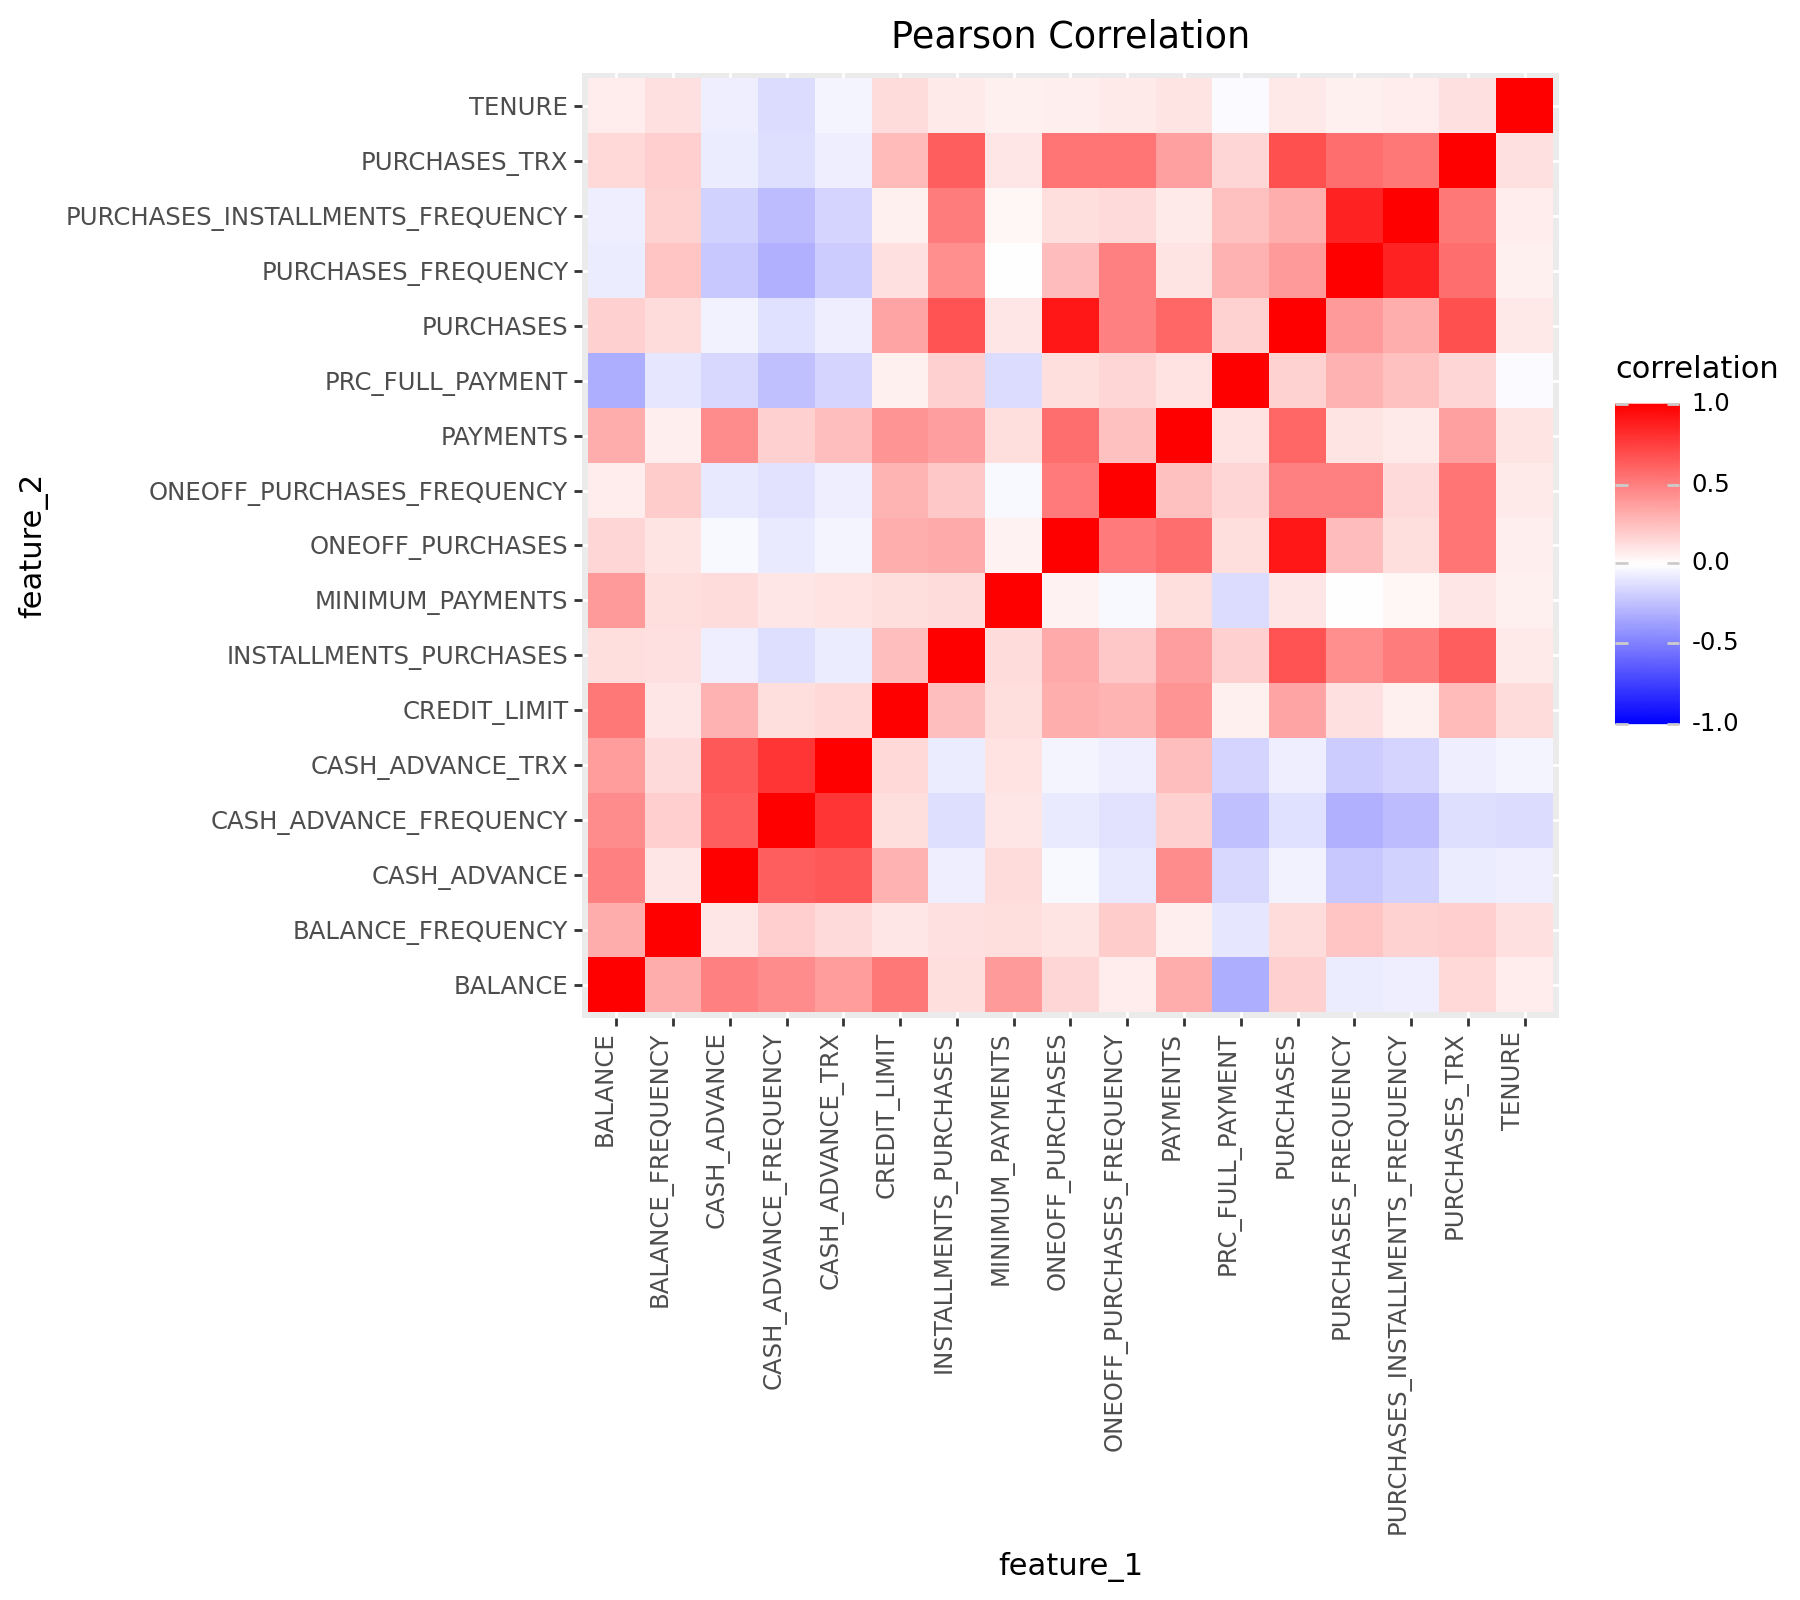

In [108]:
pearson_corr = df[numeric_cols].corr(method="pearson")
spearman_corr = df[numeric_cols].corr(method="spearman")
corr_diff = (spearman_corr - pearson_corr)

def corr_heatmap(matrix, title):
    long = matrix.reset_index().melt(id_vars="index")
    long.columns = ["feature_1", "feature_2", "correlation"]
    return (
        pln.ggplot(long, pln.aes("feature_1", "feature_2", fill="correlation"))
        + pln.geom_tile()
        + pln.scale_fill_gradient2(low="blue", mid="white", high="red", midpoint=0, limits=(-1, 1))
        + pln.theme(axis_text_x=pln.element_text(rotation=90, hjust=1), figure_size=(9, 8))
        + pln.labs(title=title)
    )

corr_heatmap(pearson_corr, "Pearson Correlation")

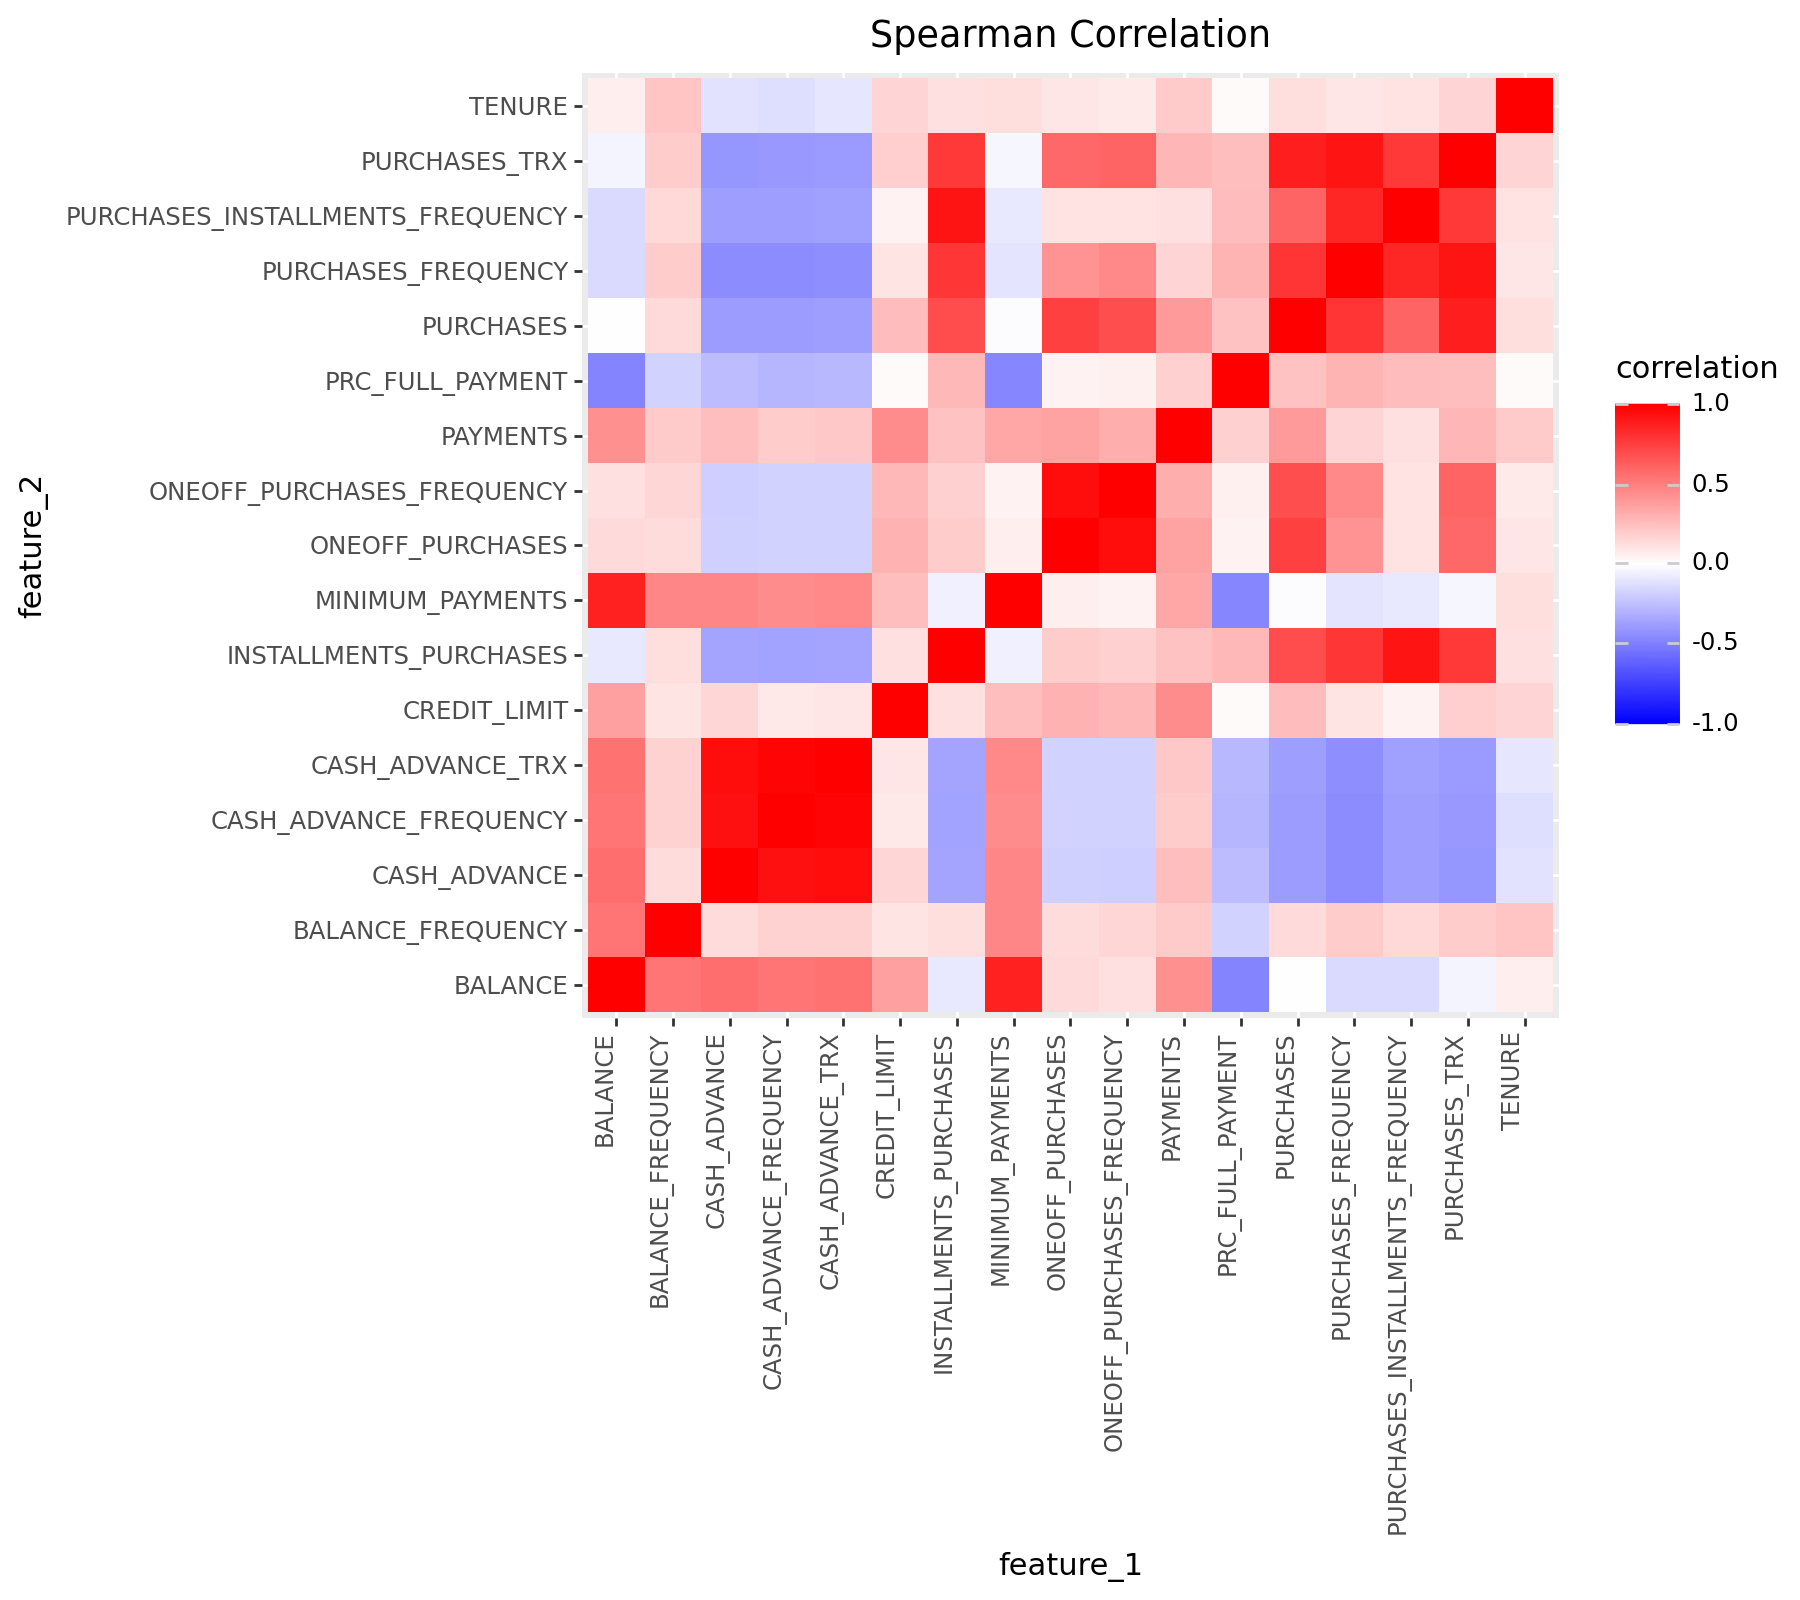

In [109]:
corr_heatmap(spearman_corr, "Spearman Correlation")

In [110]:
# Pairs where Spearman and Pearson disagree the most (excluding self-correlation)
diff_long = corr_diff.reset_index().melt(id_vars="index")
diff_long.columns = ["feature_1", "feature_2", "diff"]
diff_long = diff_long[diff_long["feature_1"] != diff_long["feature_2"]]
diff_long["abs_diff"] = diff_long["diff"].abs()
diff_long.sort_values("abs_diff", ascending=False).drop_duplicates(subset="abs_diff").head(15)

,feature_1,feature_2,diff,abs_diff
238,BALANCE,MINIMUM_PAYMENTS,0.473441,0.473441
58,ONEOFF_PURCHASES_FREQUENCY,ONEOFF_PURCHASES,0.427556,0.427556
140,INSTALLMENTS_PURCHASES,PURCHASES_INSTALLMENTS_FREQUENCY,0.412095,0.412095
104,PURCHASES,PURCHASES_FREQUENCY,0.401551,0.401551
184,MINIMUM_PAYMENTS,CASH_ADVANCE_TRX,0.356857,0.356857
193,PURCHASES_FREQUENCY,PURCHASES_TRX,0.355161,0.355161
167,MINIMUM_PAYMENTS,CASH_ADVANCE_FREQUENCY,0.352067,0.352067
74,PURCHASES_FREQUENCY,INSTALLMENTS_PURCHASES,0.344048,0.344048
253,PRC_FULL_PAYMENT,MINIMUM_PAYMENTS,-0.341597,0.341597
239,BALANCE_FREQUENCY,MINIMUM_PAYMENTS,0.340663,0.340663


##### *Discussion — Pearson vs Spearman*

The 15 pairs with the largest |Spearman − Pearson| gap are dominated by one clear pattern:
an **amount** variable paired with its corresponding **frequency/count** variable —
`ONEOFF_PURCHASES` vs `ONEOFF_PURCHASES_FREQUENCY` (Δ=0.43), `PURCHASES` vs
`PURCHASES_FREQUENCY` (Δ=0.40), `INSTALLMENTS_PURCHASES` vs
`PURCHASES_INSTALLMENTS_FREQUENCY` (Δ=0.41), `PURCHASES_FREQUENCY` vs `PURCHASES_TRX`
(Δ=0.36), and several `MINIMUM_PAYMENTS`/`CASH_ADVANCE` combinations (Δ≈0.34–0.36).

This is exactly what the extreme skewness identified earlier would predict: the amount
variables are dominated by a small number of very large values, which suppresses their
*linear* (Pearson) correlation with a bounded, well-behaved variable like frequency — even
though, in rank terms, "more frequent activity" and "more total amount" move together almost
perfectly monotonically (high Spearman). Pearson is therefore **understating** the true
strength of these relationships.

A second, distinct pattern also stands out: negative gaps between `PURCHASES`/`PURCHASES_TRX`
and `CASH_ADVANCE`/`CASH_ADVANCE_TRX` (Δ≈ -0.32 to -0.33). Spearman is *more negative* than
Pearson here, suggesting two roughly mutually exclusive customer behaviors — "purchase-driven"
spenders vs. "cash-advance-driven" spenders — expressed consistently in rank order but blurred
in the raw linear correlation by the zero-inflation on both sides (most customers do very
little of either).

Notably, structurally related pairs like `PURCHASES` vs `ONEOFF_PURCHASES` (which is almost
additively part of `PURCHASES`) do **not** appear in this top-15 divergence list — meaning
their Pearson and Spearman correlations already agree closely, consistent with a genuinely
near-linear relationship.

**Implication for PCA (Section 3):** PCA is built on covariance, i.e. on the Pearson notion
of "relatedness." Since several of the data's strongest true relationships are monotonic but
not linear, raw PCA is likely to under-represent them in the leading components. This is a
concrete argument for log-transforming the heavily right-skewed monetary features
(`PURCHASES`, `CASH_ADVANCE`, `MINIMUM_PAYMENTS`, `PAYMENTS`, `BALANCE`) before PCA, so that
their linear correlation structure moves closer to their true monotonic structure.

### *Distribution Analysis*

For each major feature: histogram, boxplot, skewness, kurtosis.

#### *Skewness and Kurtosis*

**Skewness** measures how asymmetric a distribution is around its mean.

| Range | Interpretation |
|---|---|
| ≈ 0 | Symmetric (like a normal distribution) |
| \|skew\| < 0.5 | Approximately symmetric |
| 0.5 < \|skew\| < 1 | Moderately skewed |
| \|skew\| > 1 | Strongly skewed |
| skew > 0 | **Right (positive) skew** — long right tail, mean > median. Most values are low/concentrated, while a small minority reaches very high extreme values (e.g. `PURCHASES`, `CASH_ADVANCE` — most customers spend little, a small minority spends a lot) |
| skew < 0 | **Left (negative) skew** — long left tail, mean < median. Most values are high, while a small minority reaches very low extreme values (e.g. `TENURE`, skew = -2.9 — most customers have long tenure, a small minority has very short tenure) |

**Kurtosis**: kurtosis is a single continuous number, not just two
named states — it measures "how much weight sits in the tails relative to the center,"
normalized by variance. The full range looks like this:

| Value | Regime | Shape |
|---|---|---|
| **-2** (absolute theoretical minimum) | — | Two point masses exactly at the extremes, nothing in between — the most "U-shaped" a distribution can possibly be (e.g. a symmetric Bernoulli on {0,1}) |
| -2 to -1.2 | Bathtub / U-shaped | Mass concentrated near both edges, less in the middle |
| **-1.2** | Uniform | Perfectly flat — no concentration anywhere |
| ≈ 0 | Mesokurtic | Normal-like tails |
| > 0, increasing | Leptokurtic | Sharper central peak *and* heavier, more extreme tails as the value grows |

Note that -1.2 is the kurtosis of a continuous uniform distribution, and -2 is the
absolute lower bound for any distribution's excess kurtosis — so a value approaching -2
(rather than just "negative") is the specific signature of a bathtub/edge-concentrated
shape, distinct from a merely flat/uniform one.

**Important:** kurtosis alone cannot fully determine the shape, because it is a single
number and many different distributions can share the same value. A mildly negative
kurtosis can come from either a truly uniform distribution or a mild bathtub shape; a
high positive kurtosis can come from either a symmetric heavy-tailed distribution or a
sharp near-zero peak with a small extreme minority (as seen in `MINIMUM_PAYMENTS` here).
In both cases, the histogram is needed to tell the shapes apart — kurtosis narrows down
the hypothesis, it does not confirm it on its own.


In [111]:
skew_kurt = pd.DataFrame({
    "skewness": df[numeric_cols].apply(lambda x: skew(x.dropna())),
    "kurtosis": df[numeric_cols].apply(lambda x: kurtosis(x.dropna())),
}).sort_values("skewness", ascending=False)

skew_kurt

,skewness,kurtosis
MINIMUM_PAYMENTS,13.850125,293.555553
ONEOFF_PURCHASES,10.043399,164.095191
PURCHASES,8.142904,111.325882
INSTALLMENTS_PURCHASES,7.297897,96.520563
PAYMENTS,5.906630,54.739472
CASH_ADVANCE_TRX,5.720339,61.611758
CASH_ADVANCE,5.165743,52.869216
PURCHASES_TRX,4.629879,34.772995
BALANCE,2.392985,7.669794
PRC_FULL_PAYMENT,1.942494,2.430366


#### *Histograms & Boxplots per Feature*

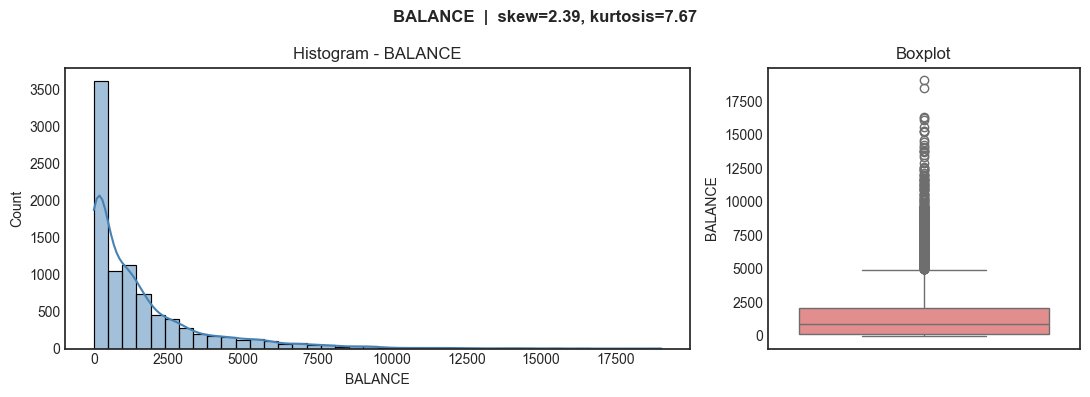

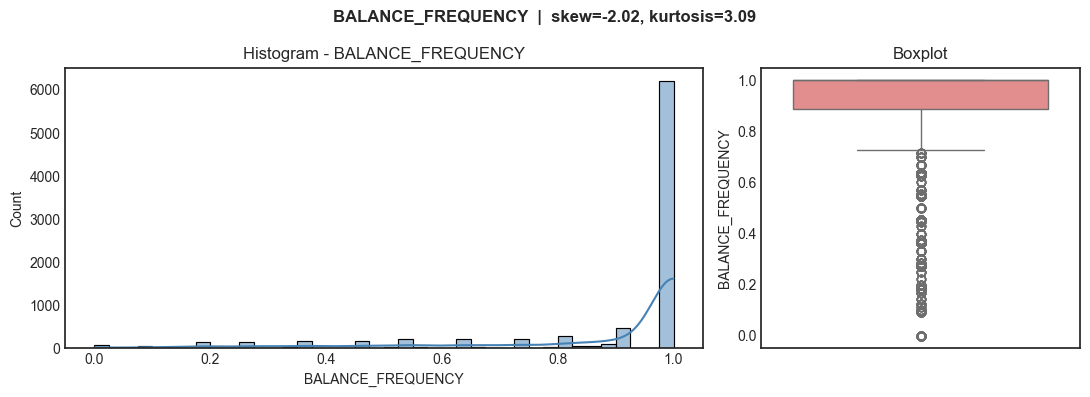

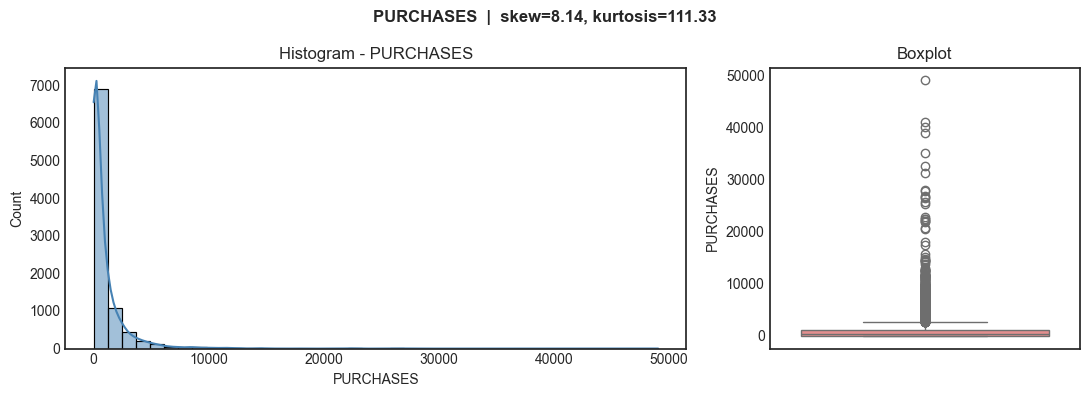

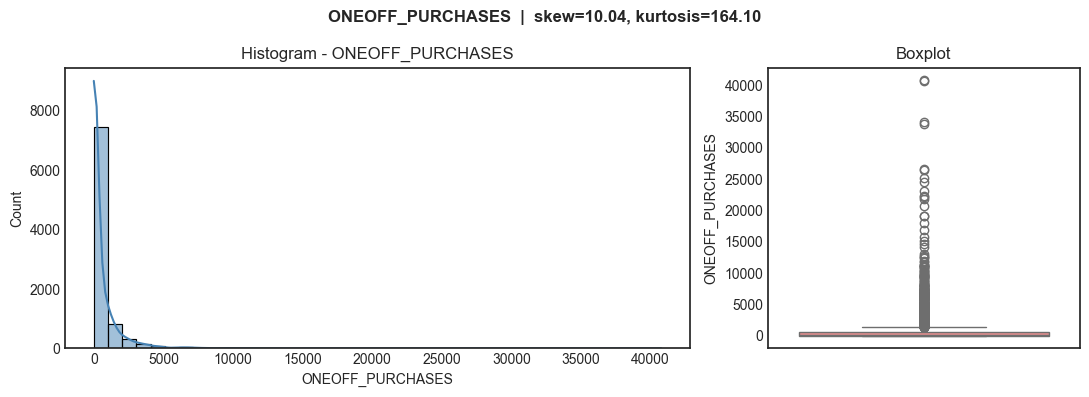

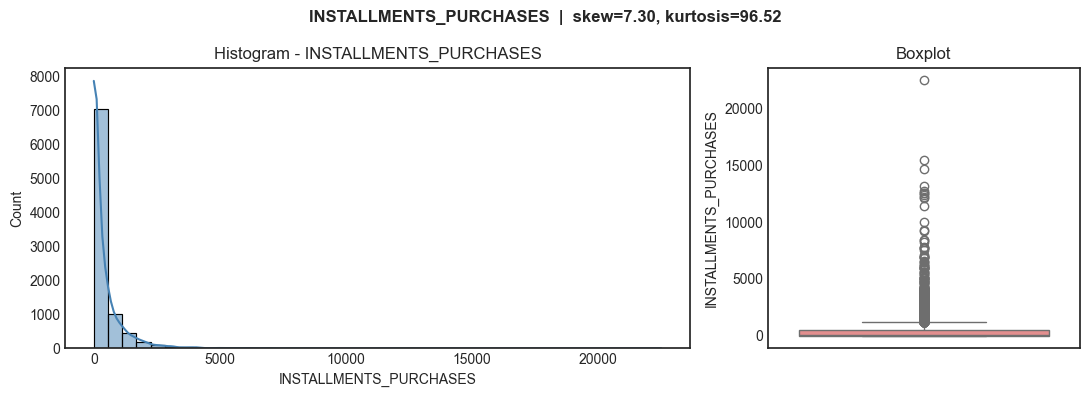

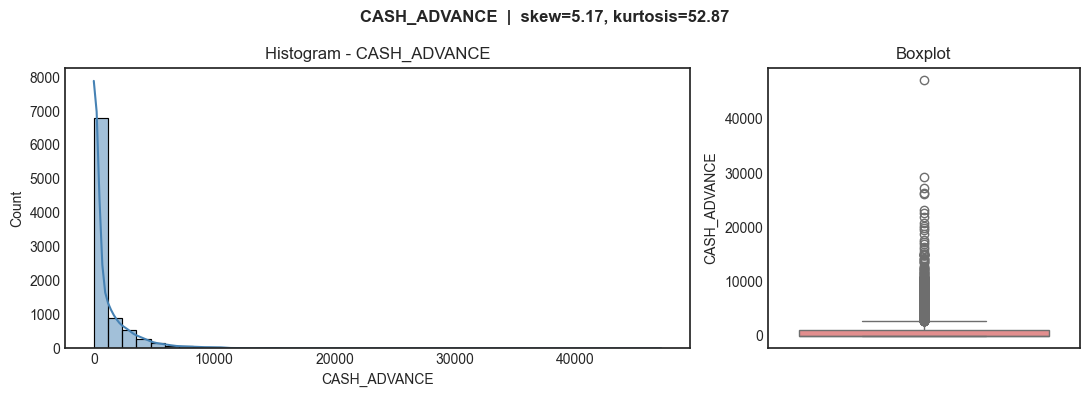

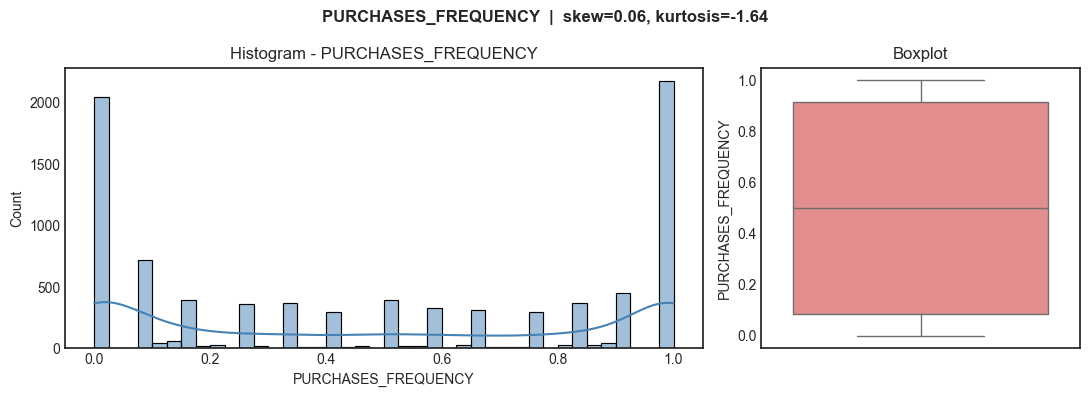

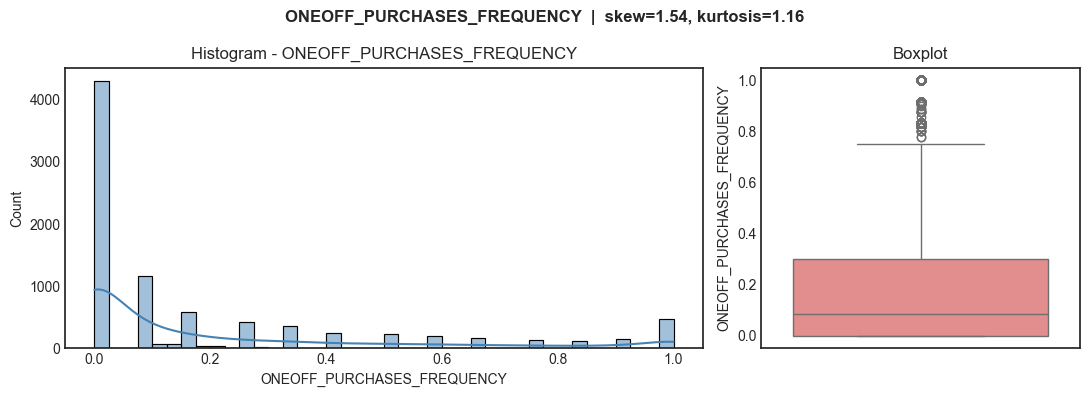

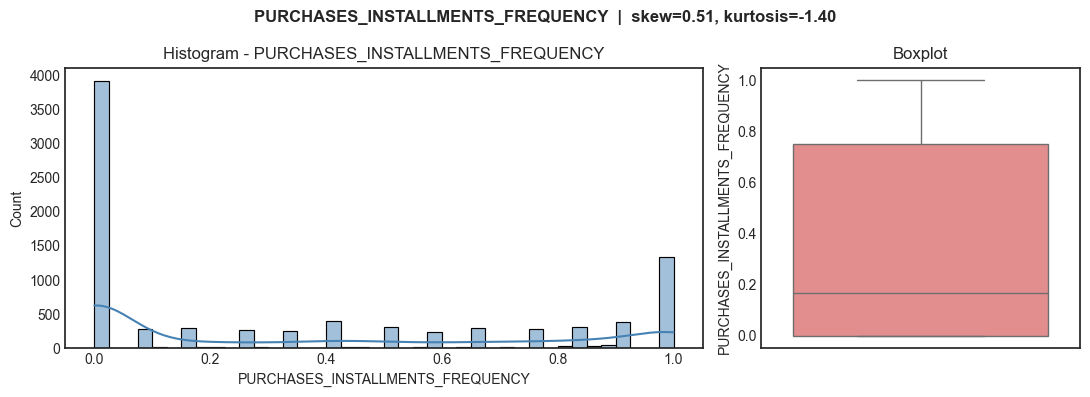

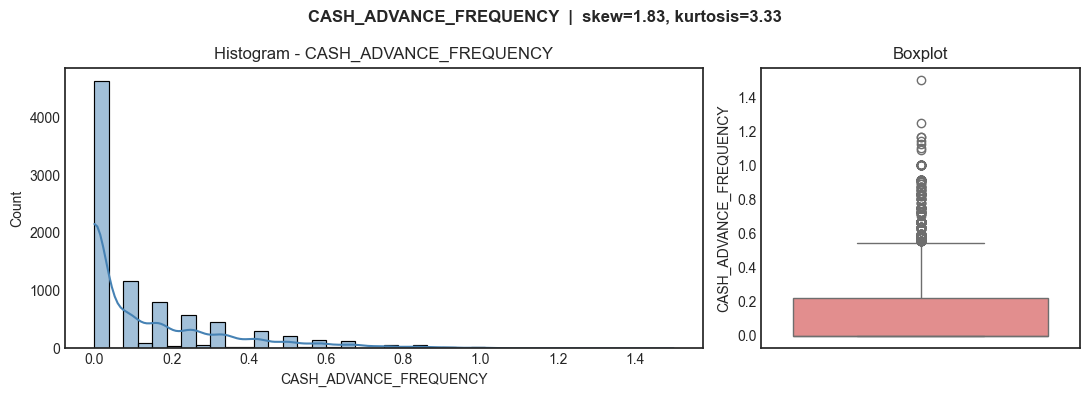

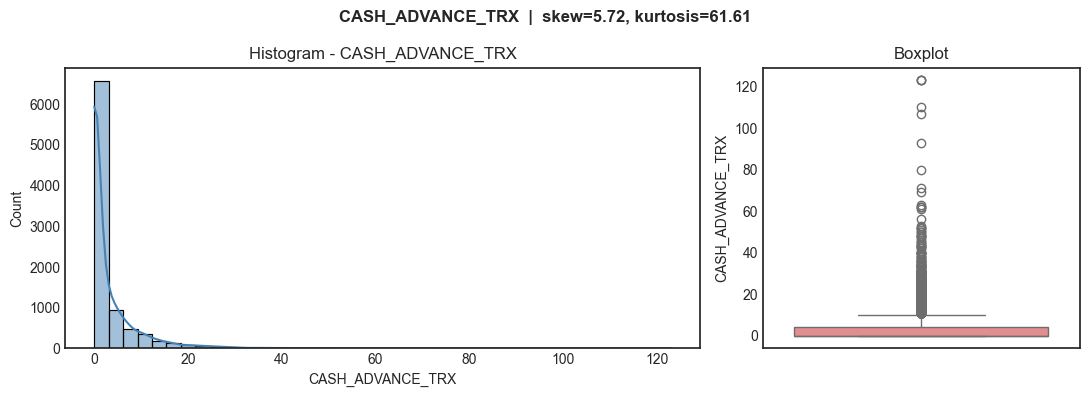

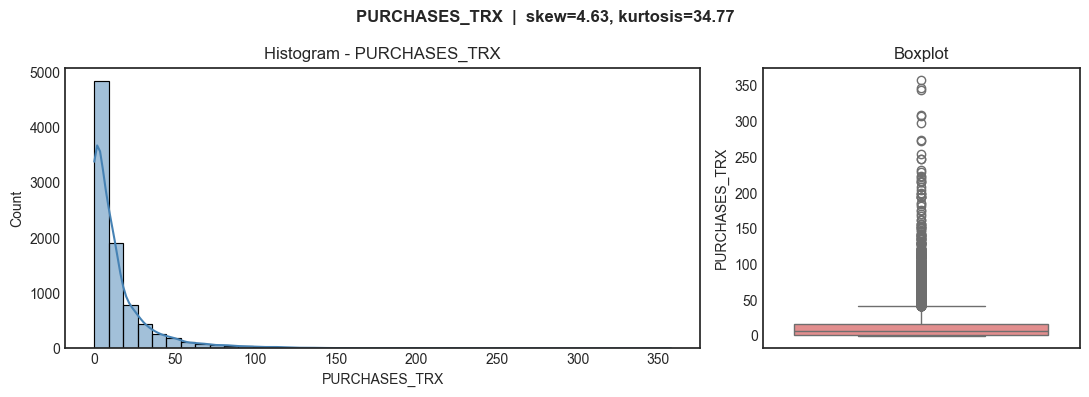

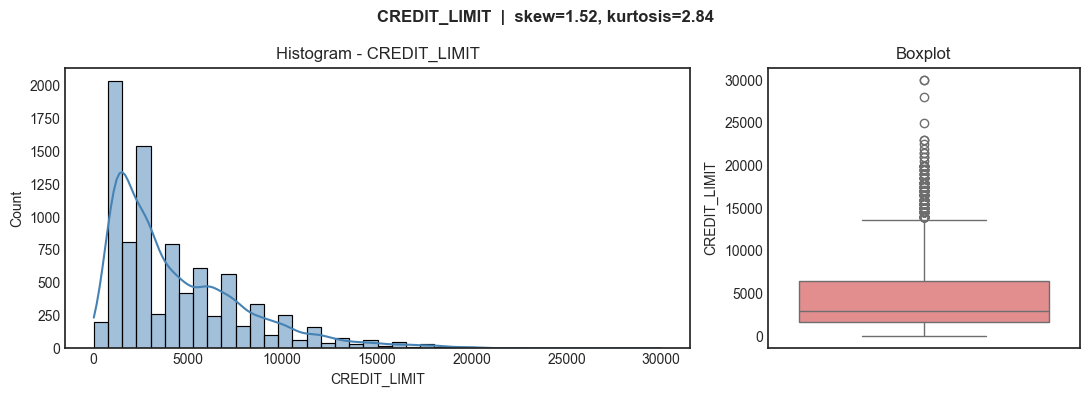

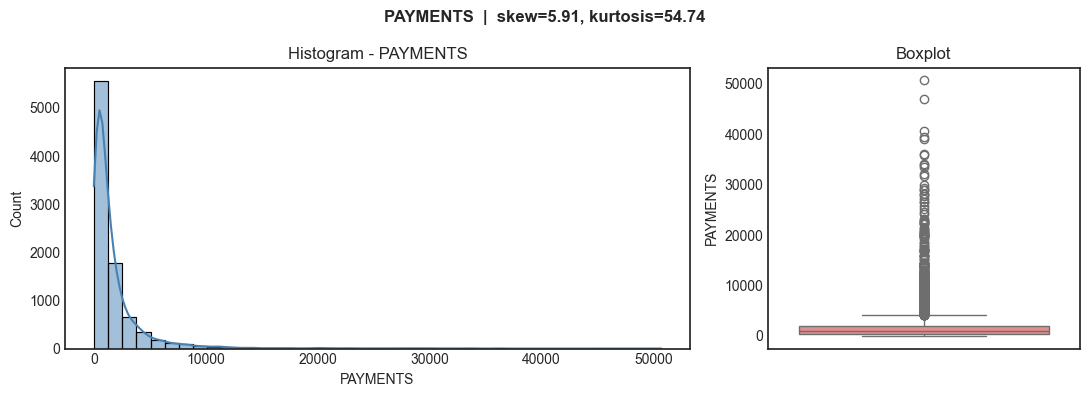

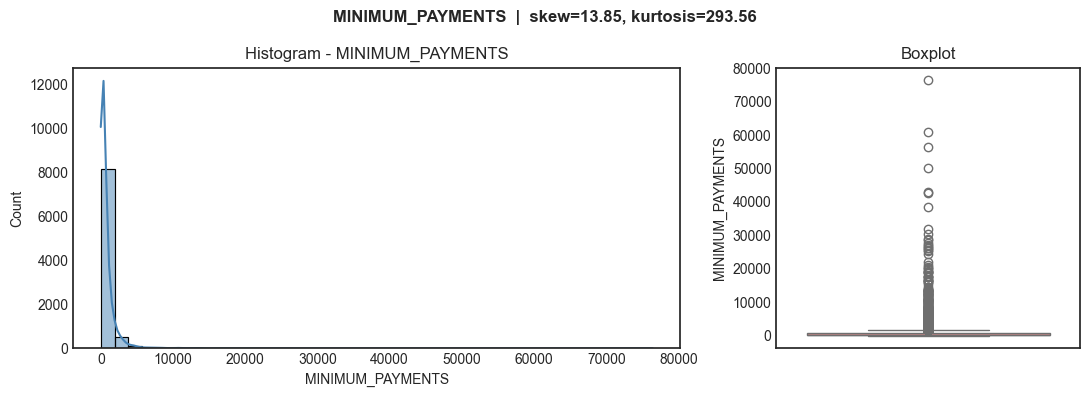

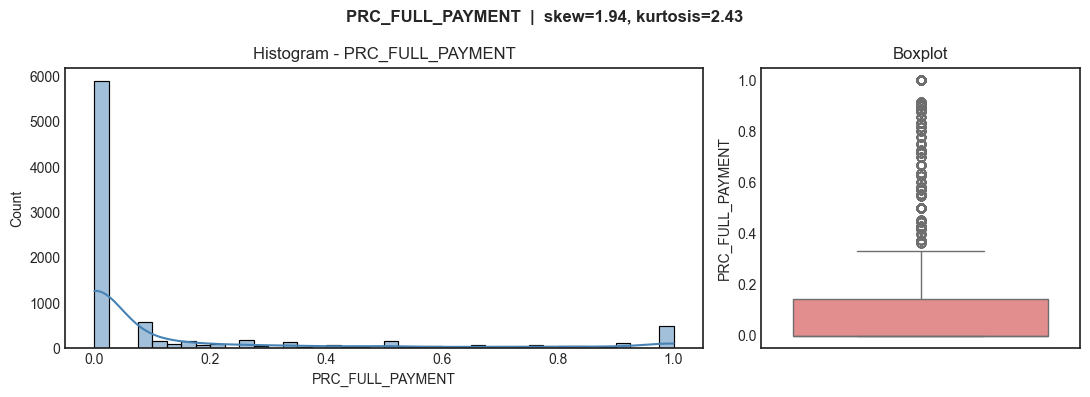

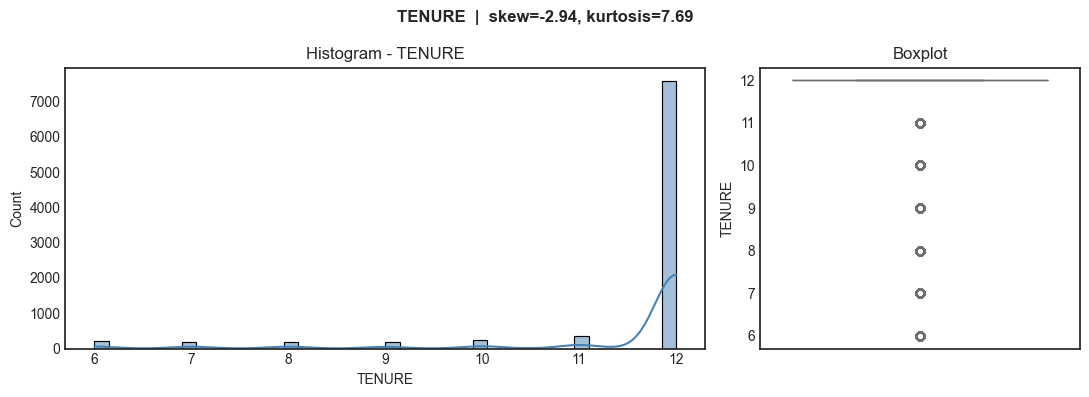

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_variable_summary(col, data):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [2, 1]})

    sns.histplot(data[col].dropna(), bins=40, kde=True, ax=axes[0], color="steelblue")
    axes[0].set_title(f"Histogram - {col}")

    sns.boxplot(y=data[col].dropna(), ax=axes[1], color="lightcoral")
    axes[1].set_title("Boxplot")

    s, k = skew_kurt.loc[col, "skewness"], skew_kurt.loc[col, "kurtosis"]
    fig.suptitle(f"{col}  |  skew={s:.2f}, kurtosis={k:.2f}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

for col in numeric_cols:
    plot_variable_summary(col, df)

#### *Discussion — Distributions*



The skewness/kurtosis table confirms a strong right-skew across nearly every monetary and
count feature: `MINIMUM_PAYMENTS` (skew=13.85, kurtosis=293.56), `ONEOFF_PURCHASES`
(skew=10.04, kurtosis=164.10), `PURCHASES` (skew=8.14, kurtosis=111.33), and
`INSTALLMENTS_PURCHASES` (skew=7.30, kurtosis=96.52) are the most extreme. Economically, this
reflects the reality of consumer spending: the vast majority of customers spend modestly (or
not at all) in any given category, while a small minority of "big spenders" or "cash-advance
users" drives amounts far above the typical range — the classic long-tailed shape of financial
behavior data, not a data-quality problem.

`MINIMUM_PAYMENTS_WAS_MISSING` also shows high skew/kurtosis (5.06 / 23.63), but this is a
statistical artifact of it being a binary flag with only ~3.5% ones — it should not be
interpreted as a "distribution shape" finding the way the continuous features are.

`TENURE` is the most left-skewed feature (skew=-2.94, kurtosis=7.69). This is explained by a
ceiling effect visible in `describe()`: the 25th, 50th, and 75th percentiles are all exactly
12 — meaning at least three-quarters of customers have the maximum tenure of 12 months, with
only a minority holding the card for less time. This produces a sharp right-side spike (hence
positive/leptokurtic kurtosis) with a thin left tail, rather than a smooth bell shape.

The boxplots make this skew visually striking: because a handful of extreme high-value
customers force the y-axis to span the full range, the IQR box and whiskers for the
monetary features collapse into a thin sliver near the bottom of the plot, and only the
scattered extreme points remain clearly visible — creating the visual impression that
"almost everything is outside the IQR," even though the numeric outlier rates computed
above show this is not the case. This is a direct visual consequence of the skewness
already quantified above, not a plotting artifact or a data problem.

At the other extreme, `PURCHASES_FREQUENCY` (skew=0.06, kurtosis=-1.64) and
`PURCHASES_INSTALLMENTS_FREQUENCY` (skew=0.51, kurtosis=-1.40) are the two most platykurtic
features — close to a flat spread across [0,1]. Looking at their histograms directly (not just
the summary statistics) is necessary to confirm whether this reflects a genuinely even spread
of purchase habits across the customer base, or a bimodal concentration at the two endpoints
(customers who purchase "never" vs. "almost every month") — skewness/kurtosis alone cannot
distinguish between the two, as noted above.

**Implication:** the combination of extreme right-skew in monetary variables and near-uniform
spread in frequency variables means a single global scaling strategy (e.g. StandardScaler
alone) will not be sufficient before PCA/clustering — the monetary variables will need a
log-transform (or similar) first, while the frequency variables are likely fine on their
original scale.

### *Outlier Exploration*

#### *IQR-based Outlier Rates*

In [113]:
def iqr_outlier_pct(col):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((df[col] < lower) | (df[col] > upper)).mean() * 100

outlier_pct = pd.Series({col: iqr_outlier_pct(col) for col in numeric_cols}).sort_values(ascending=False)
outlier_pct

BALANCE_FREQUENCY                   16.681564
PRC_FULL_PAYMENT                    16.469274
TENURE                              15.262570
CASH_ADVANCE                        11.508380
ONEOFF_PURCHASES                    11.318436
MINIMUM_PAYMENTS                    10.156425
INSTALLMENTS_PURCHASES               9.687151
PAYMENTS                             9.027933
PURCHASES                            9.027933
CASH_ADVANCE_TRX                     8.983240
ONEOFF_PURCHASES_FREQUENCY           8.737430
PURCHASES_TRX                        8.558659
BALANCE                              7.765363
CASH_ADVANCE_FREQUENCY               5.865922
CREDIT_LIMIT                         2.770950
PURCHASES_INSTALLMENTS_FREQUENCY     0.000000
PURCHASES_FREQUENCY                  0.000000
dtype: float64

##### *Discussion — IQR-based Outlier Rates*

The two highest outlier rates in the table — `BALANCE_FREQUENCY` (16.68%) and `TENURE`
(15.26%) — are almost certainly methodological artifacts rather than real anomalies. Both
variables are heavily concentrated near their maximum value (`BALANCE_FREQUENCY` has a
median and 75th percentile of 1.0; `TENURE` has median = 75th percentile = 12). When most
of the data sits at a ceiling, the IQR becomes very narrow, so the 1.5×IQR rule flags a
large share of otherwise ordinary, lower-but-valid values.

By contrast, the monetary features (`CASH_ADVANCE` 11.51%, `ONEOFF_PURCHASES` 11.32%,
`MINIMUM_PAYMENTS` 10.16%, `PURCHASES`/`PAYMENTS` ~9.0%) show economically meaningful
outlier rates — these are the genuine "big spender" / "high cash-advance user" customers
already identified via skewness.

At the opposite extreme, `PURCHASES_FREQUENCY` and `PURCHASES_INSTALLMENTS_FREQUENCY` show
exactly 0% — consistent with their near-uniform, platykurtic shape: with no tight central
cluster, the IQR rule has nothing extreme to flag against, even if the histogram reveals a
real concentration at the endpoints.

**Takeaway:** the classical univariate IQR rule is informative for the continuous monetary
features but not appropriate for bounded [0,1] frequency features or for `TENURE` given its
ceiling effect — a point worth carrying into Section 5, where Z-score will face the same
Gaussianity problem even more directly.

#### *Data-Entry & Range Sanity Checks*

Beyond statistical outliers, it is worth verifying that the data does not contain
logically impossible values — signs of a data-entry error rather than a genuine extreme
observation. Two checks are performed:


(1) whether any of the `_FREQUENCY` features,
which are defined as a proportion of months and should therefore lie in [0, 1], contain
values outside that range.


(2) whether any customer's `MINIMUM_PAYMENTS` exceeds
their `PAYMENTS`, which would be inconsistent (the minimum required payment cannot be
larger than what the customer actually paid).

In [114]:
# Sanity checks: logical consistency and valid ranges for bounded/frequency features
freq_cols = [c for c in numeric_cols if "FREQUENCY" in c]
range_violations = {c: ((df[c] < 0) | (df[c] > 1)).sum() for c in freq_cols}

payment_violation = (df["MINIMUM_PAYMENTS"] > df["PAYMENTS"]).sum()

print("Out-of-[0,1]-range violations per frequency feature:", range_violations)
print(f"Rows where MINIMUM_PAYMENTS > PAYMENTS: {payment_violation}")

Out-of-[0,1]-range violations per frequency feature: {'BALANCE_FREQUENCY': np.int64(0), 'PURCHASES_FREQUENCY': np.int64(0), 'ONEOFF_PURCHASES_FREQUENCY': np.int64(0), 'PURCHASES_INSTALLMENTS_FREQUENCY': np.int64(0), 'CASH_ADVANCE_FREQUENCY': np.int64(8)}
Rows where MINIMUM_PAYMENTS > PAYMENTS: 2638


##### *Discussion — Data-Entry & Range Sanity Checks*

The [0,1] range check found only 8 violations (0.09% of rows), all in
`CASH_ADVANCE_FREQUENCY` — a small enough count to plausibly be a rounding artifact from
how the ratio was computed, rather than a systematic data-quality problem, but worth a
direct look at the affected rows before drawing a conclusion.

The `MINIMUM_PAYMENTS > PAYMENTS` check requires a correction to the assumption stated
above: this condition is not actually a logical impossibility. It occurs for 2,638 rows
(~29.5% of customers) — far too high a share to reflect data-entry errors. It far more
plausibly reflects a real and common credit-card behavior: paying less than the required
minimum (a partial or missed payment). Rather than a data-quality flag, this is itself a
potentially meaningful behavioral signal — these customers may be exactly the kind of
"at-risk" segment worth revisiting during anomaly detection in Section 5.

## *3. Dimensionality Reduction*

### *3.1 Principal Component Analysis (PCA)*

#### *Mathematical Background: Eigenvectors, Eigenvalues, and What PCA Optimizes*


Let $X$ be our standardized data matrix ($n$ customers × $p$ features, each column with
mean 0 and variance 1). PCA looks for a new set of axes — linear combinations of the
original features — that are (a) orthogonal to each other and (b) ordered so that the
first axis captures as much of the data's variance as possible, the second captures as
much of the *remaining* variance as possible, and so on.

**The covariance matrix.** For standardized data, the sample covariance matrix is

$$\Sigma = \frac{1}{n-1} X^T X$$

$\Sigma$ is a $p \times p$ symmetric matrix. Its diagonal entries are the variances of
each feature (all equal to 1, since we standardized); its off-diagonal entries are the
pairwise covariances (equivalently, Pearson correlations, since the data is standardized)
— this is exactly the same matrix we already computed and visualized in Section 2 as the
Pearson correlation heatmap.

**Eigenvectors and eigenvalues.** A vector $v$ is an eigenvector of $\Sigma$ with
eigenvalue $\lambda$ if

$$\Sigma v = \lambda v$$

Geometrically: applying $\Sigma$ to $v$ doesn't rotate $v$ — it only stretches it, by a
factor of $\lambda$. PCA's key result (from linear algebra) is that **the directions of
maximum variance in the data are exactly the eigenvectors of $\Sigma$**, and the amount of
variance captured along each direction is exactly its eigenvalue. Since $\Sigma$ is
symmetric, it has $p$ real eigenvalues $\lambda_1 \geq \lambda_2 \geq \dots \geq \lambda_p$
with orthogonal eigenvectors $v_1, v_2, \dots, v_p$ — these eigenvectors *are* the
principal components, ranked from most to least variance explained.

**Explained variance ratio.** Since the total variance in the data equals
$\sum_i \lambda_i$, the fraction of variance captured by component $i$ is simply

$$\text{explained variance ratio of PC}_i = \frac{\lambda_i}{\sum_{j=1}^{p} \lambda_j}$$

— exactly the `explained_variance_ratio_` column computed below.

**A tiny worked example.** Suppose we had just two standardized features with a strong
correlation $\rho = 0.8$ between them (a simplified stand-in for a pair like `PURCHASES`
and `PURCHASES_TRX`). Their covariance matrix is

$$\Sigma = \begin{pmatrix} 1 & 0.8 \\ 0.8 & 1 \end{pmatrix}$$

Solving $\det(\Sigma - \lambda I) = 0$ gives $(1-\lambda)^2 = 0.64$, so
$\lambda_1 = 1.8$ and $\lambda_2 = 0.2$. The corresponding eigenvectors are
$v_1 = \frac{1}{\sqrt2}(1, 1)$ and $v_2 = \frac{1}{\sqrt2}(1, -1)$ — i.e. the *sum* of the
two variables (their shared, common direction) captures $1.8 / (1.8+0.2) = 90\%$ of the
variance, while their *difference* (the direction in which they disagree) captures only
10%. This is the geometric essence of what we'll see below: when features are strongly
correlated, PCA collapses them into one dominant direction, and the redundancy shows up
as a small number of components carrying most of the variance.

**Loadings.** Each principal component is a linear combination of the original
(standardized) features:

$$\text{PC}_i = v_{i,1} x_1 + v_{i,2} x_2 + \dots + v_{i,p} x_p$$

The coefficients $v_{i,1}, \dots, v_{i,p}$ — the entries of eigenvector $v_i$ — are called
the **loadings**. A large positive loading means that feature pulls the component up when
it's high; a large negative loading means it pulls the component down. Reading the sign
and magnitude of the loadings is how we interpret what each abstract "PC" actually means
in terms of real customer behavior.

#### *Preprocessing for PCA*

Two preprocessing steps are required before applying PCA, both motivated directly by
findings from Section 2:

1. **Log-transform (`log1p`) for right-skewed features** (skewness > 1, per the
   `skew_kurt` table). PCA is built on the covariance matrix, which is highly sensitive to
   extreme values — a handful of customers with `MINIMUM_PAYMENTS` in the tens of
   thousands (skewness = 13.85) would dominate the variance calculation and distort the
   eigenvectors, even after standardization (standardization only rescales, it does not
   change the *shape* of a distribution). `log1p(x) = log(1+x)` compresses large values
   much more than small ones, pulling the extreme tail in while leaving zeros well-defined
   — and, as discussed in Section 2, it moves the Pearson correlation structure closer to
   the true monotonic (Spearman) relationships we found between these variables.
2. **Standardization (`StandardScaler`)**, so every feature has mean 0 and variance 1.
   Without this, a feature measured in raw dollars (e.g. `CREDIT_LIMIT`, up to tens of
   thousands) would mechanically dominate the covariance matrix over a feature bounded in
   [0,1] (e.g. `PURCHASES_FREQUENCY`) — not because it is more informative, but purely
   because of its measurement scale.

`MINIMUM_PAYMENTS_WAS_MISSING` is excluded from the PCA input: it is an engineered,
sparse binary flag (3.5% ones) rather than part of the continuous behavioral geometry PCA
is meant to summarize.

In [115]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_features = [c for c in numeric_cols if c != "MINIMUM_PAYMENTS_WAS_MISSING"]

# Right-skewed features (skew > 1) get log1p; log1p handles zeros gracefully (log(1+x))
right_skewed = skew_kurt.loc[pca_features][skew_kurt.loc[pca_features, "skewness"] > 1].index.tolist()
print("Log-transformed features:", right_skewed)

X = df[pca_features].copy()
for col in right_skewed:
    X[col] = np.log1p(X[col])

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=pca_features, index=X.index)

X_scaled.describe().T[["mean", "std", "min", "max"]]

Log-transformed features: ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'ONEOFF_PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT']


,mean,std,min,max
BALANCE,1.270244e-17,1.000056,-3.060633,1.834341
BALANCE_FREQUENCY,2.286439e-16,1.000056,-3.703271,0.518084
PURCHASES,6.986342e-17,1.000056,-1.679855,2.023087
ONEOFF_PURCHASES,2.540488e-17,1.000056,-0.987090,2.283062
INSTALLMENTS_PURCHASES,1.587805e-18,1.000056,-1.087454,2.163264
CASH_ADVANCE,5.716098e-17,1.000056,-0.930733,2.086805
PURCHASES_FREQUENCY,-1.841854e-16,1.000056,-1.221758,1.269843
ONEOFF_PURCHASES_FREQUENCY,2.540488e-17,1.000056,-0.732480,2.466762
PURCHASES_INSTALLMENTS_FREQUENCY,4.604634e-17,1.000056,-0.916995,1.599199
CASH_ADVANCE_FREQUENCY,-2.381707e-17,1.000056,-0.724360,5.122793


#### *Explained Variance*

`pca_full.explained_variance_ratio_` returns $\lambda_i / \sum_j \lambda_j$ for every
component — the practical output of the eigendecomposition described above. The
cumulative sum tells us how many components are needed to retain a given fraction of the
data's total variance (information).

##### *A Note on Notation: Three Different Things Called "PC1"*

The label "PC1" is used loosely to refer to three distinct mathematical objects. It is
worth being precise about which one is meant in each part of this analysis:

| Object | What it is | Where it appears below | How many numbers |
|---|---|---|---|
| $v_1$ | The eigenvector itself — a fixed **direction** in the 17-dimensional feature space. A property of the correlation matrix $\Sigma$, not of any individual customer. | The **Loadings** table/heatmap | 17 numbers (one weight per original feature) |
| $\lambda_1 / \sum_j \lambda_j$ | The **explained variance ratio** of $v_1$ — a single scalar describing how much of the total variance that direction captures. | The **Explained Variance** table and Scree Plot | 1 number (e.g. 34.2%) |
| $\text{PC}_1(j) = v_1^T x_j$ | The **coordinate** (projection score) of a specific customer $j$ onto the fixed direction $v_1$. | The **2D / 3D Projection** scatterplots | 8,950 numbers — one per customer |

These three are related but answer different questions:
- $v_1$ answers *"which combination of original features defines this axis?"*
- $\lambda_1/\sum_j\lambda_j$ answers *"how important is this axis, out of all 17?"*
- $\text{PC}_1(j)$ answers *"where does this particular customer fall along that axis?"*

All three come from the same eigendecomposition step,
$$\Sigma v_i = \lambda_i v_i, \qquad i = 1, \dots, 17,$$
which yields 17 eigenvector/eigenvalue pairs at once — not one at a time. Sorting them by
decreasing $\lambda_i$ and calling the largest one "PC1" is a labeling convention applied
*after* solving this equation, not a separate computation.

In [116]:
pca_full = PCA(n_components=len(pca_features), random_state=42)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

variance_table = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca_features))],
    "explained_variance_ratio": explained_var,
    "cumulative_variance": cumulative_var,
})
variance_table

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.341827,0.341827
1,PC2,0.220830,0.562657
2,PC3,0.095124,0.657780
3,PC4,0.073720,0.731501
4,PC5,0.066334,0.797835
5,PC6,0.049788,0.847623
6,PC7,0.041840,0.889463
7,PC8,0.030939,0.920402
8,PC9,0.025001,0.945403
9,PC10,0.016205,0.961608


#### *Scree Plot*

The scree plot shows explained variance ratio per component in decreasing order. The
classic "elbow method" looks for the point where the curve flattens — components before
the elbow capture substantial, distinct variance; components after it contribute only
marginal, increasingly noise-like variance. The dashed red line marks $1/p$ — the variance
share a component would carry if all $p$ features were completely uncorrelated (the "no
redundancy" baseline); components above it are doing more work than chance would predict.

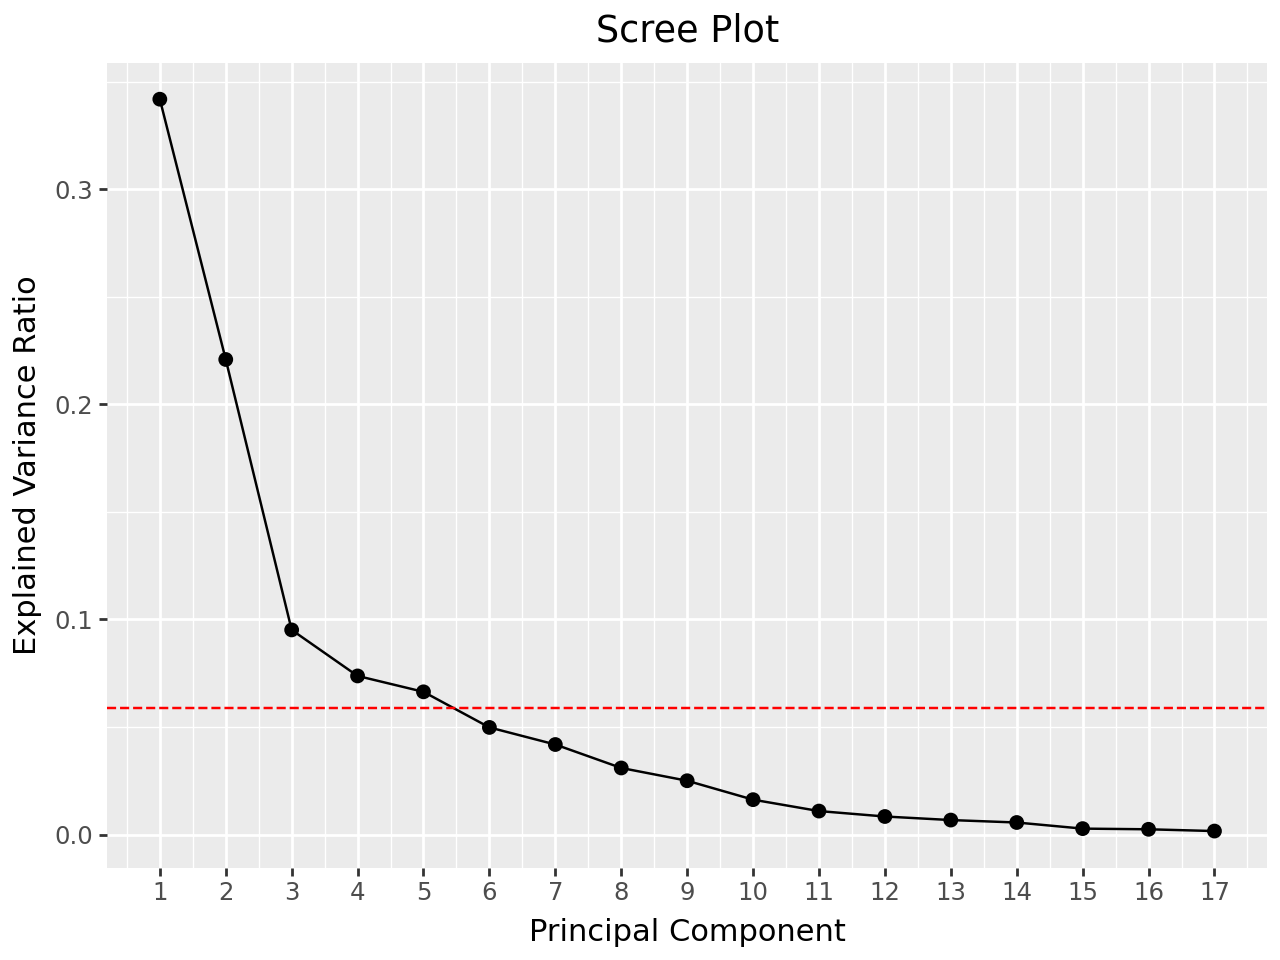

In [117]:
scree_df = variance_table.copy()
scree_df["component_num"] = range(1, len(scree_df) + 1)

(
    pln.ggplot(scree_df, pln.aes(x="component_num", y="explained_variance_ratio"))
    + pln.geom_line()
    + pln.geom_point(size=2)
    + pln.geom_hline(yintercept=1/len(pca_features), linetype="dashed", color="red")
    + pln.labs(title="Scree Plot", x="Principal Component", y="Explained Variance Ratio")
    + pln.scale_x_continuous(breaks=list(scree_df["component_num"]))
)

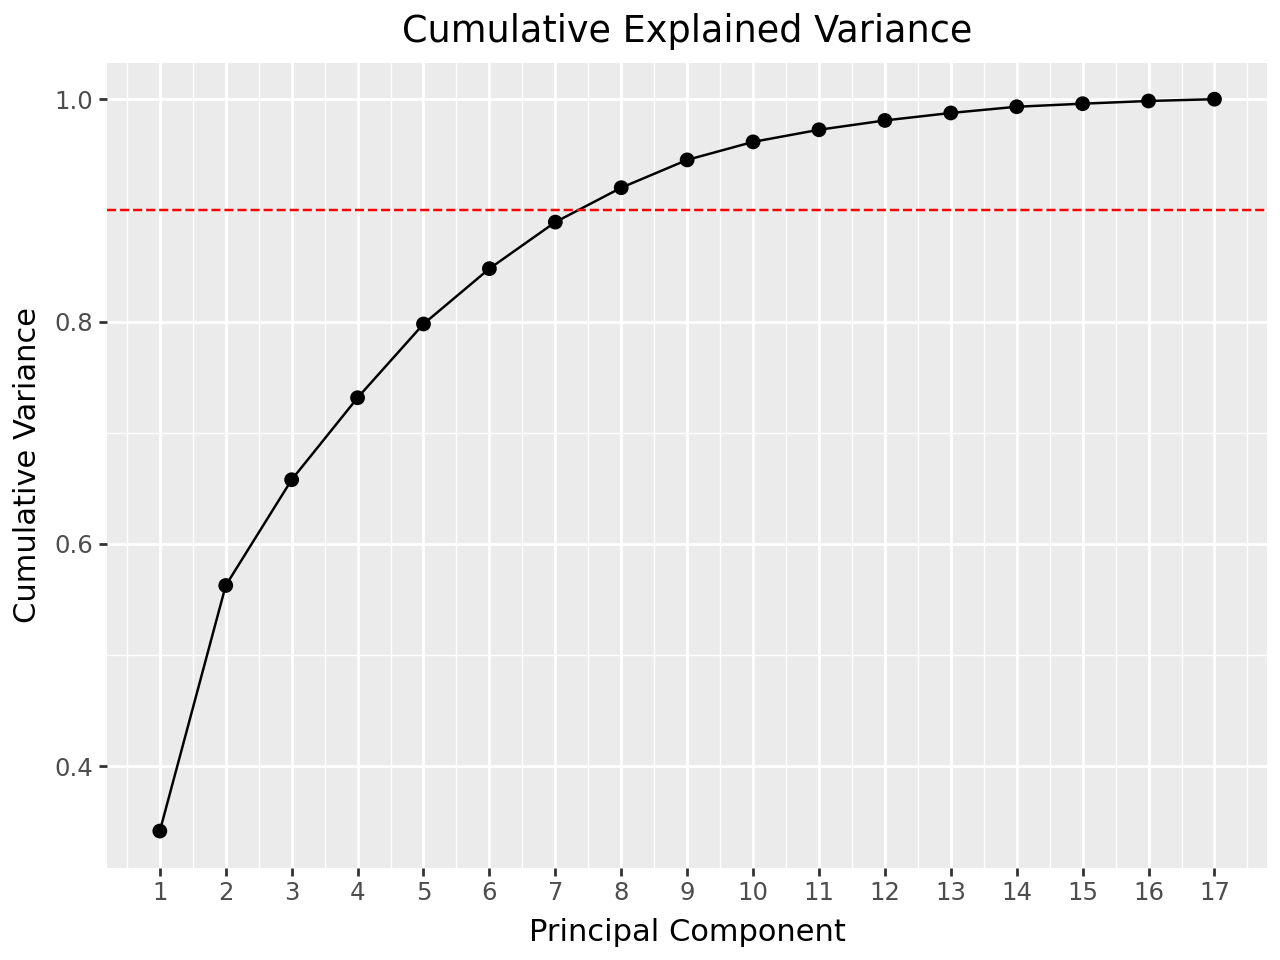

In [118]:
(
    pln.ggplot(scree_df, pln.aes(x="component_num", y="cumulative_variance"))
    + pln.geom_line()
    + pln.geom_point(size=2)
    + pln.geom_hline(yintercept=0.90, linetype="dashed", color="red")
    + pln.labs(title="Cumulative Explained Variance", x="Principal Component", y="Cumulative Variance")
    + pln.scale_x_continuous(breaks=list(scree_df["component_num"]))
)


#### *2D Projection*

Intuitively, this is like taking a 2D "shadow" of a 17-dimensional object: each customer
lives as a point in a 17-dimensional space, and this plot flattens that point down onto
just the two directions of greatest spread ($v_1$, $v_2$), the same way a 3D object casts
a flat shadow when light hits it from one particular angle. A shadow can look very
informative — you might be able to recognize a shape — but it can never show you every
detail of the true 3D object at once.

Concretely, this projection captures $34.2\% + 22.1\% = 56.3\%$ of the data's total
variance ($\lambda_1/\sum_j\lambda_j + \lambda_2/\sum_j\lambda_j$) — meaning that with just
2 out of the original 17 dimensions, we can still visually account for just over half of
all the variability across customers. That is a meaningful compression (17 numbers per
customer down to 2), but it also means the remaining $43.7\%$ of each customer's true
position — their spread along PC3 through PC17 — is invisible here. Two points that look
close together on this plot are not guaranteed to be similar customers; they are only
guaranteed to be similar *along these two particular directions*.

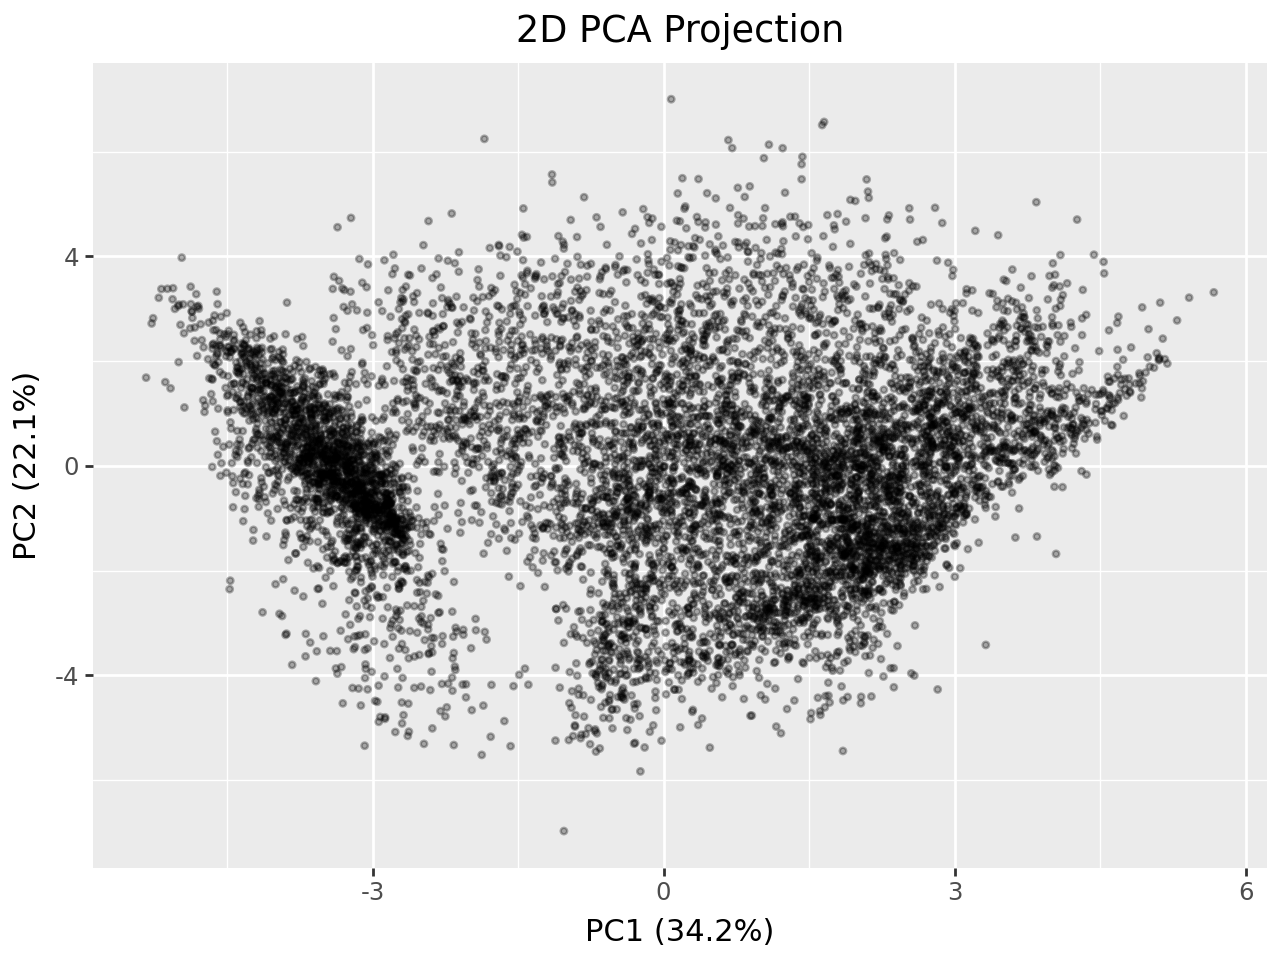

In [119]:
pca_2d = PCA(n_components=2, random_state=42)
components_2d = pca_2d.fit_transform(X_scaled)

proj_2d = pd.DataFrame(components_2d, columns=["PC1", "PC2"], index=X_scaled.index)

(
    pln.ggplot(proj_2d, pln.aes(x="PC1", y="PC2"))
    + pln.geom_point(alpha=0.3, size=0.8)
    + pln.labs(
        title="2D PCA Projection",
        x=f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})",
        y=f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})",
    )
)

#### *3D Projection*

Same idea extended to $v_1, v_2, v_3$ — a slightly less lossy view of the data's dominant
structure, at the cost of being harder to inspect visually than a flat 2D plot.

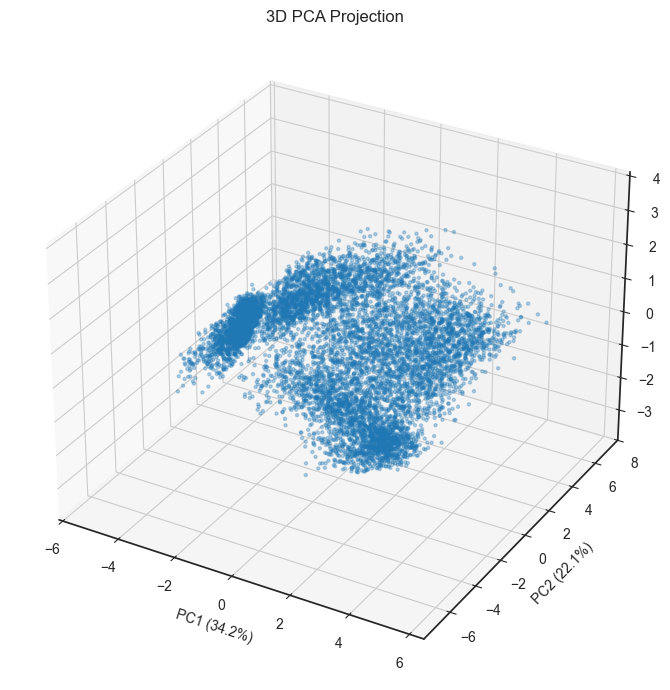

In [120]:
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3, random_state=42)
components_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(components_3d[:, 0], components_3d[:, 1], components_3d[:, 2], alpha=0.3, s=5)
ax.set_xlabel(f"PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})")
ax.set_zlabel(f"PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})")
ax.set_title("3D PCA Projection")
plt.tight_layout()
plt.show()

#### *Principal Component Loadings*

The heatmap below shows the full loading matrix — $v_{i,j}$ for every original feature $j$
across the first four components. The printed lists that follow it show, for each
$\text{PC}_i$, only the **top 5 features by absolute loading** — the 5 largest-magnitude
weights out of the 17 that make up $v_i$ — since those dominate the interpretation, not
the smaller remaining weights.

Each printed value is $v_{i,j}$, the coefficient of feature $j$ in the linear combination
that defines $\text{PC}_i$:

$$\text{PC}_1 = v_{1,1}\cdot x_1 + v_{1,2}\cdot x_2 + \dots + v_{1,17}\cdot x_{17}$$

Two things to read off each number:
- **Sign:** whether that feature pushes $\text{PC}_i$ up (+) or down (−). When several
  top features share the same sign, it means they all move together along that axis — a
  customer high in one tends to be high in $\text{PC}_i$ via all of them at once.
- **Magnitude:** how strongly that feature contributes, relative to the others. Because
  $v_i$ is a unit vector ($\sum_j v_{i,j}^2 = 1$), its "weight budget" is fixed — no single
  feature can dominate with an arbitrarily large coefficient. Several similarly-sized top
  loadings (as seen in PC1's top 5, all in the 0.31–0.37 range) indicate the axis is
  genuinely a blend of correlated features, not driven by one variable alone.

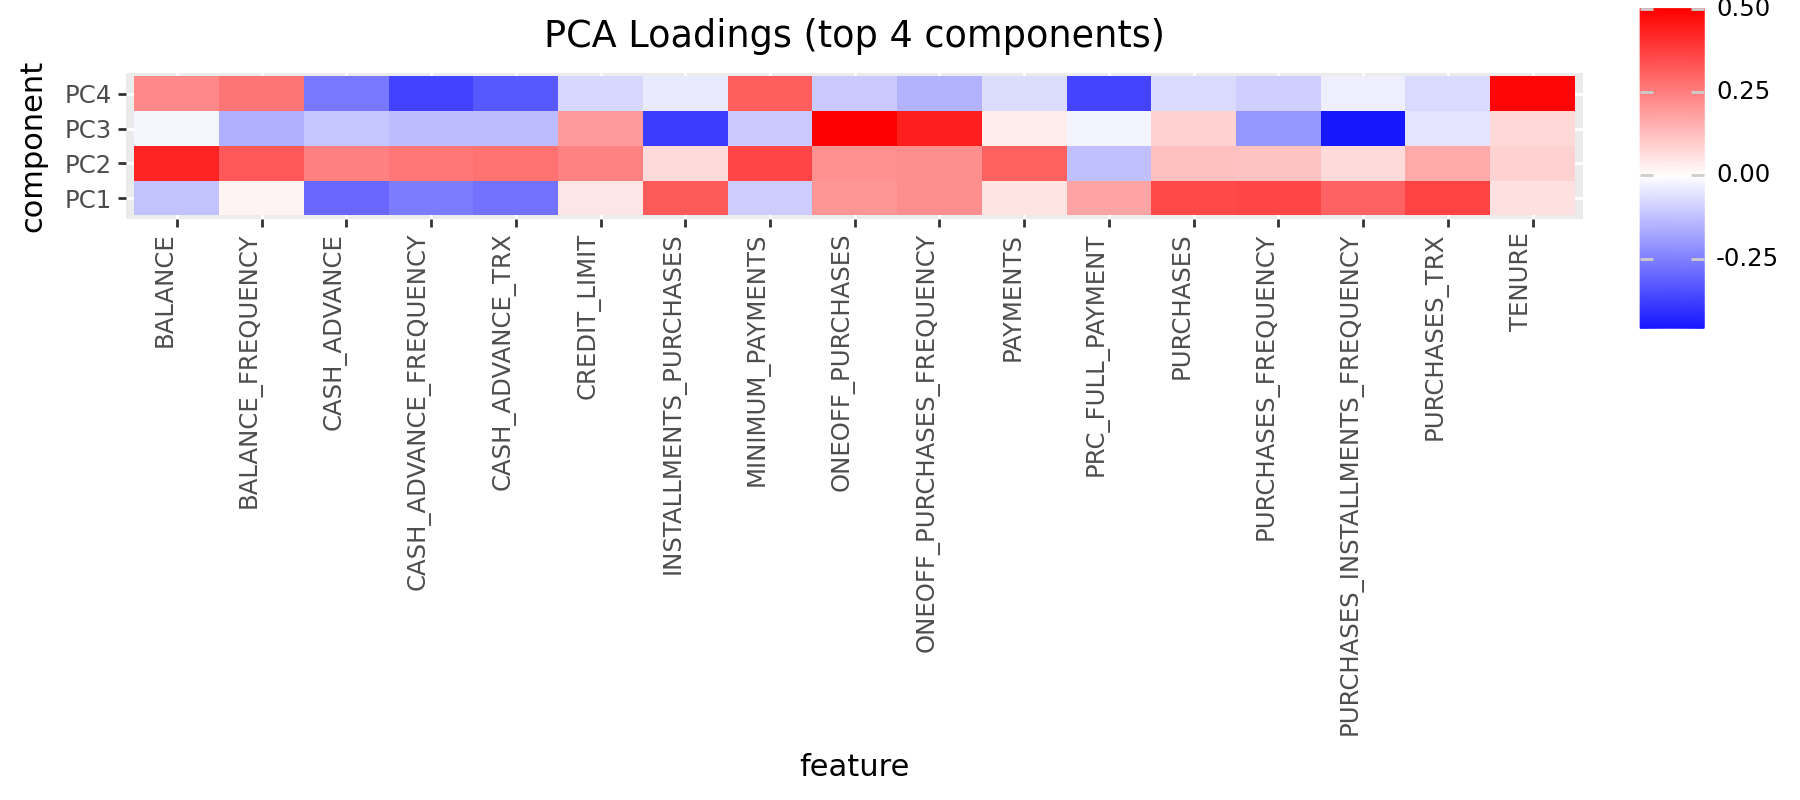

In [121]:
n_top_pcs = 4
loadings = pd.DataFrame(
    pca_full.components_[:n_top_pcs].T,
    index=pca_features,
    columns=[f"PC{i+1}" for i in range(n_top_pcs)],
)

loadings_long = loadings.reset_index().melt(id_vars="index")
loadings_long.columns = ["feature", "component", "loading"]

(
    pln.ggplot(loadings_long, pln.aes(x="feature", y="component", fill="loading"))
    + pln.geom_tile()
    + pln.scale_fill_gradient2(low="blue", mid="white", high="red", midpoint=0)
    + pln.theme(axis_text_x=pln.element_text(rotation=90, hjust=1), figure_size=(9, 4))
    + pln.labs(title="PCA Loadings (top 4 components)")
)

In [122]:
for i in range(n_top_pcs):
    pc = f"PC{i+1}"
    top_features = loadings[pc].abs().sort_values(ascending=False).head(5)
    print(f"\n{pc} — top contributing features:")
    for feat in top_features.index:
        print(f"  {feat}: {loadings.loc[feat, pc]:+.3f}")


PC1 — top contributing features:
  PURCHASES_TRX: +0.374
  PURCHASES_FREQUENCY: +0.364
  PURCHASES: +0.363
  INSTALLMENTS_PURCHASES: +0.325
  PURCHASES_INSTALLMENTS_FREQUENCY: +0.311

PC2 — top contributing features:
  BALANCE: +0.435
  MINIMUM_PAYMENTS: +0.366
  BALANCE_FREQUENCY: +0.329
  PAYMENTS: +0.315
  CASH_ADVANCE_TRX: +0.281

PC3 — top contributing features:
  ONEOFF_PURCHASES: +0.505
  PURCHASES_INSTALLMENTS_FREQUENCY: -0.461
  ONEOFF_PURCHASES_FREQUENCY: +0.447
  INSTALLMENTS_PURCHASES: -0.384
  PURCHASES_FREQUENCY: -0.209

PC4 — top contributing features:
  TENURE: +0.492
  CASH_ADVANCE_FREQUENCY: -0.373
  PRC_FULL_PAYMENT: -0.371
  CASH_ADVANCE_TRX: -0.332
  MINIMUM_PAYMENTS: +0.317


#### *Discussion — Explained Variance, PC Interpretation & Redundancy*


The scree plot shows a steep initial drop — PC1 (34.2%), PC2 (22.1%), PC3 (9.5%) — followed
by a much more gradual decline (PC4–PC7 each between 4–7%). The "elbow" sits around PC2–PC3,
suggesting 2–3 components already capture the data's dominant structure. However, this
elbow only accounts for 65.8% of total variance (PC1+PC2+PC3), and reaching a conventional
90% threshold requires **8 components** (cumulative = 92.0% at PC8) out of the original 17.
This is a genuine tension worth stating explicitly: a *visually* compact low-dimensional
summary (2–3 axes) exists, but it is not a *complete* one — roughly a third of the data's
variance lives outside the first three components.

The loadings clarify what the leading components represent:
- **PC1** is dominated by `PURCHASES_TRX` (+0.374), `PURCHASES_FREQUENCY` (+0.364),
  `PURCHASES` (+0.363), `INSTALLMENTS_PURCHASES` (+0.325), `PURCHASES_INSTALLMENTS_FREQUENCY`
  (+0.311) — all positive, all measuring purchase *activity*. This mirrors the toy 2-variable
  example above: because these five features are strongly correlated (as already seen in
  the Section 2 Pearson/Spearman analysis), PCA collapses them into one dominant "general
  purchase engagement" axis.
- **PC2** is dominated by `BALANCE` (+0.435), `MINIMUM_PAYMENTS` (+0.366),
  `BALANCE_FREQUENCY` (+0.329), `PAYMENTS` (+0.315) — a "balance / debt-carrying" axis,
  distinct from purchase activity.
- **PC3** contrasts `ONEOFF_PURCHASES`/`ONEOFF_PURCHASES_FREQUENCY` (positive) against
  `PURCHASES_INSTALLMENTS_FREQUENCY`/`INSTALLMENTS_PURCHASES` (negative) — a "purchase
  *style*" axis (lump-sum vs. installment), orthogonal to how *much* a customer buys.
- **PC4** mixes `TENURE` (+0.492) with `CASH_ADVANCE_FREQUENCY` (-0.373) and
  `PRC_FULL_PAYMENT` (-0.371) — less cleanly interpretable than PC1–PC3; not every
  component needs to correspond to an intuitive business story, and forcing one here would
  overstate what the data actually shows.

**Redundancy in the original data:** needing only 8 of 17 features' worth of variance to
reach 90% (a ~53% reduction) confirms substantial redundancy — consistent with the
strongly correlated feature pairs already flagged in Section 2 (e.g. `PURCHASES` almost
additively decomposing into `ONEOFF_PURCHASES` + `INSTALLMENTS_PURCHASES`). The reduced
space is more *efficient*, but Section 2 also showed several of the data's strongest
relationships are monotonic rather than linear (Spearman >> Pearson) — PCA, being a linear
method built on covariance, may still be under-representing some of that structure even
after the log-transform.

#### *Discussion — Structure, Stability & Trade-offs*


**Local vs. global structure:** the 2D projection captures only 56.3% of total variance
(PC1+PC2) — it shows the dominant global spread of the data but cannot be trusted to
preserve finer local neighborhoods; two customers that appear close in the 2D plot could
still differ meaningfully along PC3–PC8. The 3D projection (67.8% cumulative) is somewhat
better but suffers the same caveat.

**Cluster separation:** the 2D/3D scatterplots show a dense, continuous, roughly
unimodal cloud with a long tail extending along PC1 (consistent with the purchase-activity
skew already quantified in Section 2) rather than visually distinct, separated groups —
suggesting that if clusters exist (Section 4), their boundaries are likely gradual rather
than sharply separated in this projection.

**Stability:** since PC1–PC3 are each dominated by a cohesive, highly-correlated group of
features, small changes to the log-transform threshold (e.g. skew > 1 vs. skew > 1.5)
would likely leave their *interpretation* stable, though exact loading magnitudes would
shift. PC4 onward, with smaller and more mixed loadings, would likely be less stable under
such changes.

**Computational cost:** trivial here (17 features, 8,950 rows) — PCA via eigendecomposition
is $O(p^3)$ in the number of features, negligible at this scale; this would only become a
concern with hundreds or thousands of features.

**Interpretability:** PC1–PC3 translate into plain-language axes ("how much does this
customer buy," "how much balance/debt do they carry," "lump-sum vs. installment style") that
are easy to explain to a non-technical stakeholder — a genuine advantage over presenting all
17 raw features. PC4 does not offer this benefit as cleanly.

**Redundancy:** ties directly to the previous discussion block — the fact that 3 components
already explain 65.8% of variance, concentrated in interpretable, business-meaningful axes,
is itself evidence that the original 17 features encode a much lower-dimensional underlying
structure of customer behavior.